# Topic 7 Example 21

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
# Course utilities (do not modify this cell)        
import sys
import os
base_path = os.path.expanduser("~/Documents/GitHub/Signals_and_Systems")
sys.path.insert(0, base_path)
sys.path.insert(0, os.path.join(base_path, "courseutils"))

import basic_material as bm
print("Basic Material version:", bm.__version__)
bm.setup_environment()


Basic Material version: 16.002-0.1


In [3]:
colors = bm.get_colors()
j = complex(0,1)
import numpy as np
import matplotlib.pyplot as plt

from sympy import lambdify, Symbol, Piecewise
from sympy import fourier_transform, sinc, cos, pi
from sympy.abc import t,f 

import warnings
warnings.filterwarnings(
    "ignore",
    message="divide by zero encountered in divide"
)
warnings.filterwarnings(
    "ignore",
    message="invalid value encountered in divide"
)

In [4]:
tlim = 4
tt = np.linspace(-tlim, tlim, 1000)
flim = 2
ff = np.linspace(-flim, flim, 1000)

def my_rect(p):
    return Piecewise((0, t <= -p/2),(1, t <= p/2),(0, True))

p = Symbol('p')
sincu = lambda t,p: sinc(p*pi*t) # swithc to sinc ftn that evetyone else uses...

## Windowing

In [5]:
# Cosine that is zeroed for |t| > 2
SS6 = my_rect(4)*cos(pi*t)
lam_SS6 = lambdify(t, SS6, modules=['numpy'])

In [6]:
QSS6 = fourier_transform(SS6, t, f)
lam_QSS6 = lambdify(f, QSS6, modules=['numpy'])

def QSS6_analytic(f):
    return 2*np.sinc(4*f-2) + 2*np.sinc(4*f+2) ## numpy sinc doesn't require the pi, sympy's does

In [7]:
QSS6

Piecewise((2.0, Eq(f, -1/2) | Eq(f, 1/2)), (4*f*sin(4*pi*f)/(pi*(4*f**2 - 1)), True))

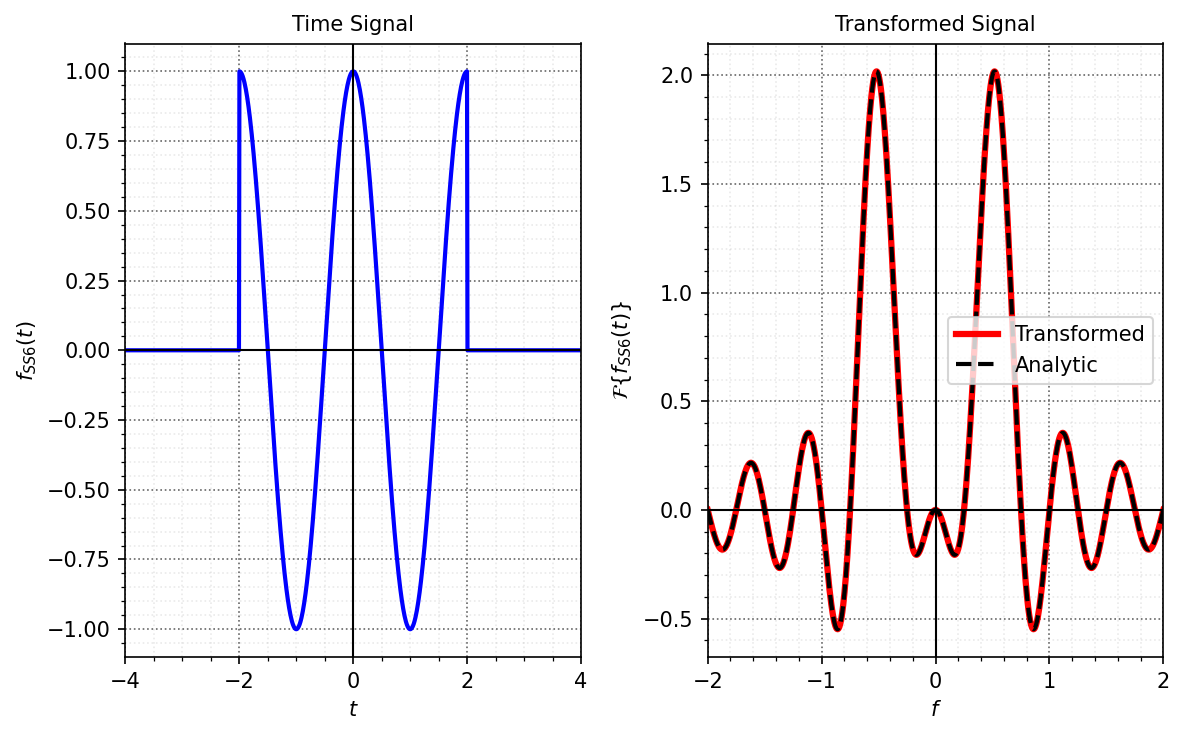

In [8]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(8,5), dpi=150)
ax1.plot(tt, lam_SS6(tt), 'b-', lw=2)
ax1.set_title('Time Signal')
ax1.set_ylabel('$f_{SS6}(t)$')
ax1.set_xlabel('$t$')
bm.nicegrid(ax1)

ax2.plot(ff, lam_QSS6(ff), 'r-', lw=3,label='Transformed')
ax2.plot(ff, QSS6_analytic(ff), 'k--', lw=2,label='Analytic')
ax2.set_title('Transformed Signal')
ax2.set_ylabel('${\cal F}\{ f_{SS6}(t)\}$')
ax2.set_xlabel('$f$')
bm.nicegrid(ax2)
plt.legend()
plt.show()

## Example 2

In [9]:
p = 2 # scaling on the windowing
m = 0.25 # scaling on the freq of the signal

tlim = int(p/2)+1
tt = np.linspace(-tlim, tlim, 1000)
flim = m+3
ff = np.linspace(-flim, flim, 1000)

# Cosine that is zeroed for |t| > 2
SS_21 = my_rect(p)*cos(m*2*pi*t)
lam_SS_21 = lambdify(t, SS_21)

In [10]:
QSS_21 = fourier_transform(SS_21, t, f)
lam_QSS_21 = lambdify(f, QSS_21)

def QSS_21_analytic(f):
    return (np.sinc(p*(f-m)) + np.sinc(p*(f+m)))*p/2 ## numpy sinc doesn't require the pi, sympy's does

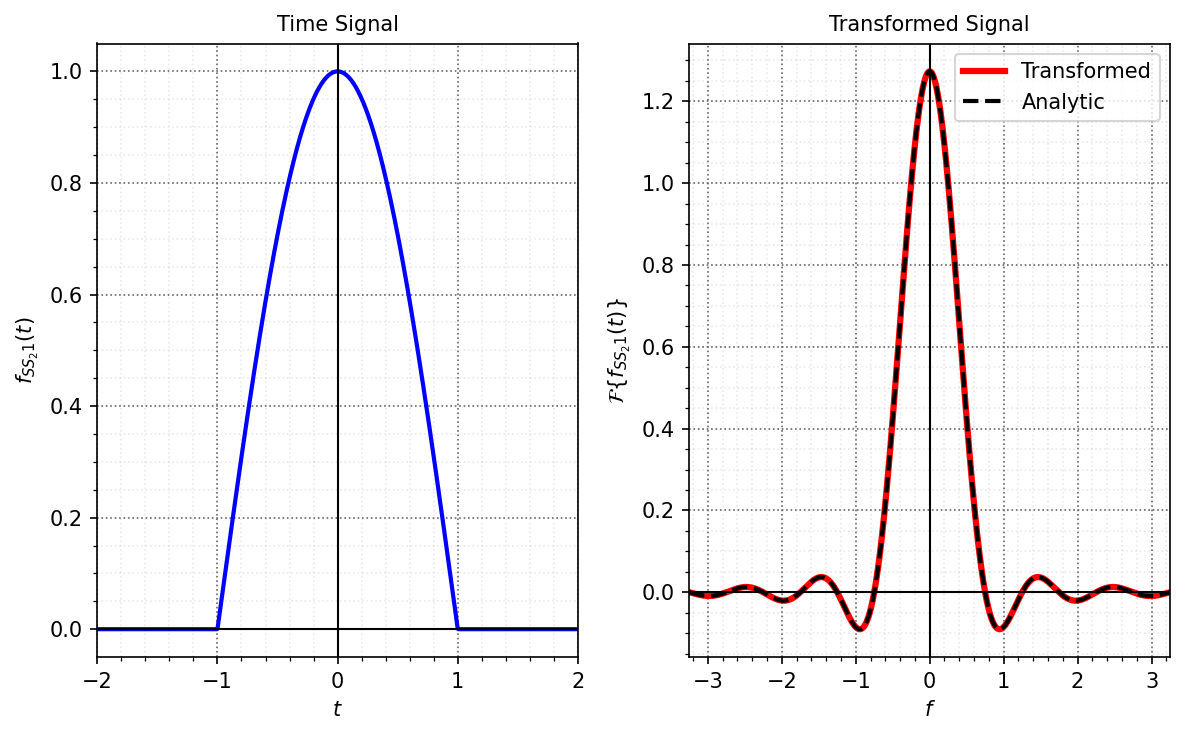

In [11]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(8,5), dpi=150)
ax1.plot(tt, lam_SS_21(tt), 'b-', lw=2)
ax1.set_title('Time Signal')
ax1.set_ylabel('$f_{SS_21}(t)$')
ax1.set_xlabel('$t$')
bm.nicegrid(ax1)

ax2.plot(ff, lam_QSS_21(ff), 'r-', lw=3,label='Transformed')
ax2.plot(ff, QSS_21_analytic(ff), 'k--', lw=2,label='Analytic')
ax2.set_title('Transformed Signal')
ax2.set_ylabel('${\cal F}\{ f_{SS_21}(t)\}$')
ax2.set_xlabel('$f$')
bm.nicegrid(ax2)
plt.legend()
plt.show()